In [4]:
# %%

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at


In [5]:
import sys
print(sys.version)
print(sys.executable)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
C:\ProgramData\miniconda3\envs\social_filters\python.exe


In [6]:
# %%
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_4_radius"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 32.0  # time after onset to include

# Lista de peces que quieres procesar
fish_ids = [
    "L654_f05",
    "L676_f04",
    "L676_f01",
    "L676_f02",
    "L676_f03",
    "L676_f04",
    "L676_f05",
    "L676_f06",
]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]

        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],

        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L654_f05 ===
✅ Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L654_f05_Exp_4_radius\03_analysis\functional\plots\significant_traces\L654_f05_significant_traces.npz
✅ Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L654_f05_Exp_4_radius\03_analysis\functional\plots\filtered_neurons_by_stimuli\L654_f05_kept_neuron_indices.npy
✅ Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L654_f05_Exp_4_radius\03_analysis\functional\suite2P\merged_dFoF\L654_f05_dFoF_merged_filtered_roi_indices.npy
✅ Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L654_f05_Exp_4_radius\03_analysis\functional\plots\z_core\L654_f05_zcore.npz
dFoF_merged_map: (1454, 6)
Loaded planes: ['plane0', 'plane1', 'plane2', 'plane3', 'plane4']
✅ Using preferred dFoF file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2

In [8]:
# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'RB': sns.color_palette('dark:#404040', 10)[7],
    'LB': sns.color_palette('dark:#404040', 10)[7],
    'RBb': sns.color_palette('Blues', 8)[7],
    'LBb': sns.color_palette('Blues', 8)[7],
    'RBc': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'LBc': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'RBd': sns.color_palette('Greens', as_cmap=True)(0.4),
    'LBd': sns.color_palette('Greens', as_cmap=True)(0.4),

}
linestyles_C = {
    'RB': '--',
    'RBb': '--',
    'RBc': '--',
    'RBd': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = [ 'RiB',
   'RB',
    'LB',
    'RBb',
    'LBb',
    'RBc',
    'LBc',
    'RBd',
    'LBd',

]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_4_radius
{'RB': '--', 'RBb': '--', 'RBc': '--', 'RBd': '--'}


In [10]:
def combine_reps_one_stim(arr, mode="concat"):
    """
    arr: (n_neurons, n_time, n_reps)
    mode: "concat" or "mean"

    Returns:
        if mode == "concat": (n_neurons, n_time * n_reps)
        if mode == "mean":   (n_neurons, n_time)
    """
    assert arr.ndim == 3, "Expected 3D array (neurons, time, reps)"
    n_neurons, n_time, n_reps = arr.shape

    if mode == "concat":
        # (N, T, R) -> (N, R, T) -> (N, R*T)
        arr_swapped = np.swapaxes(arr, 1, 2)          # (n_neurons, n_reps, n_time)
        out = arr_swapped.reshape(n_neurons, n_reps * n_time)
        return out

    elif mode == "mean":
        # average across reps axis
        out = np.nanmean(arr, axis=2)                 # (n_neurons, n_time)
        return out

    else:
        raise ValueError(f"Unknown mode '{mode}', use 'concat' or 'mean'")


def build_matrix_for_fish(trial_aligned_traces,
                          stim_order,
                          kept_neuron_indices=None,
                          combine_mode="concat"):
    """
    trial_aligned_traces: dict[stim_id] -> array (neurons, time, reps)
    stim_order: list with desired stimulus order
    kept_neuron_indices: 1D array/list of neuron indices to keep, or None
    combine_mode: "concat" or "mean"
    """
    blocks = []

    for stim in stim_order:
        # Handle int vs str keys
        if stim in trial_aligned_traces:
            arr = trial_aligned_traces[stim]
        else:
            arr = trial_aligned_traces[str(stim)]

        # 🔴 HERE we apply your kept_neuron_indices
        if kept_neuron_indices is not None:
            arr = arr[kept_neuron_indices, :, :]

        arr_block = combine_reps_one_stim(arr, mode=combine_mode)  # (N, T*reps)
        blocks.append(arr_block)

    # Concatenate horizontally along time
    fish_mat = np.concatenate(blocks, axis=1)   # (N, sum_j T_j * reps_j)
    return fish_mat

def build_matrix_all_fish(
    all_fish_data,
    stim_order,
    fish_ids=None,
    combine_mode="concat",
    trace_type="dfof",
):
    """
    all_fish_data[fish_id][...] -> dict[stim] -> (neurons, time, reps)

    Parameters
    ----------
    all_fish_data : dict
        Per-fish data container.
    stim_order : list
        Stimulus order to use when building the matrix.
    fish_ids : list, optional
        Fish IDs to include. If None, use all fish in all_fish_data.
    combine_mode : str, default="concat"
        Passed to build_matrix_for_fish.
    trace_type : str, default="dfof"
        Which trace representation to use:
        - "dfof"   -> trial_aligned_traces
        - "raster" -> trial_aligned_traces_raster
        - "zscore" -> trial_aligned_traces_z_core

    Returns
    -------
    M_all : np.ndarray
        Shape (sum_neurons_all_fish, total_time)
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    mats = []
    for fid in fish_ids:

        if trace_type == "raster":
            trial_key = "trial_aligned_traces_raster"
            kept_idx = None   # already filtered for raster version

        elif trace_type == "zscore":
            trial_key = "trial_aligned_traces_z_core"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        elif trace_type == "dfof":
            trial_key = "trial_aligned_traces"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        else:
            raise ValueError(
                f"Unknown trace_type={trace_type!r}. "
                "Use 'dfof', 'raster', or 'zscore'."
            )

        trial_aligned_traces = all_fish_data[fid][trial_key]

        M_fish = build_matrix_for_fish(
            trial_aligned_traces=trial_aligned_traces,
            stim_order=stim_order,
            kept_neuron_indices=kept_idx,
            combine_mode=combine_mode,
        )
        mats.append(M_fish)

    M_all = np.vstack(mats)

    return M_all

In [12]:
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]
print(stimuli_id_map)

{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}


Final matrix shape: (2130, 296)
✅ Saved: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis\Exp_4_radius\plots\L676_f04_dfof_as_func_of_time_pca.png


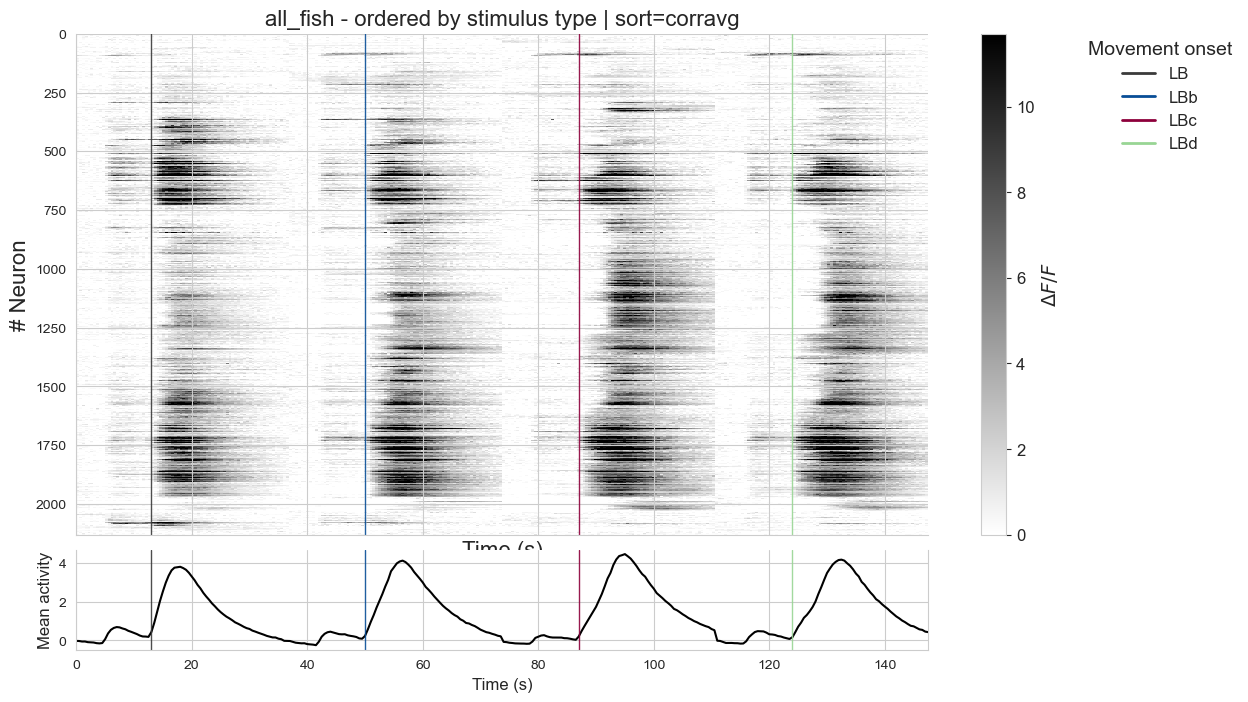

In [16]:
# plot all fish together
#{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}

#stim_order = [13,11,12,6,1,14,3]
stim_order = [4,1,2,3]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='corravg',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
)

save_path.mkdir(parents=True, exist_ok=True)
out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print("✅ Saved:", out_png)


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


def compute_mean_onsets_all_fish(
    all_fish_data,
    fish_ids=None,
    stim_order=None,
    fps_2p=2.0,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
):
    """
    For each fish and stimulus:
      - run classify_responses_from_raster
      - compute mean onset across neurons
      - compute std and sem across neurons

    Returns
    -------
    df_mean_onset : pd.DataFrame
        Columns:
        - fish_id
        - stim_id
        - mean_onset_sec
        - std_onset_sec
        - sem_onset_sec
        - n_responsive_neurons
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    fish_ids = list(dict.fromkeys(fish_ids))  # remove duplicates, keep order

    if stim_order is None:
        stim_order = all_fish_data[fish_ids[0]]["stimuli_ids"]

    rows = []
    onset_sec_by_id_all = {}
    response_type_by_id_all = {}

    for fid in fish_ids:
        fish = all_fish_data[fid]

        response_type_by_id, onset_sec_by_id = at.classify_responses_from_raster(
            raster=fish["raster"],
            onsets_by_id=fish["onsets_by_id"],
            stimuli_id_map=fish["stimuli_id_map"],
            stimuli_durations=fish["stimuli_durations"],
            fps_2p=fps_2p,
            response_window_sec=response_window_sec,
            min_run_sec=min_run_sec,
            min_fraction_trials=min_fraction_trials,
        )

        onset_sec_by_id_all[fid] = onset_sec_by_id
        response_type_by_id_all[fid] = response_type_by_id

        for stim in stim_order:
            key = stim if stim in onset_sec_by_id else str(stim)
            onset_vec = np.asarray(onset_sec_by_id[key], dtype=float)
            valid = onset_vec[np.isfinite(onset_vec)]

            rows.append({
                "fish_id": fid,
                "stim_id": stim,
                "mean_onset_sec": np.mean(valid) if len(valid) > 0 else np.nan,
                "std_onset_sec": np.std(valid, ddof=1) if len(valid) > 1 else np.nan,
                "sem_onset_sec": sem(valid),
                "n_responsive_neurons": len(valid),
            })

    df_mean_onset = pd.DataFrame(rows)
    return df_mean_onset, onset_sec_by_id_all, response_type_by_id_all


def summarize_across_fish(df_mean_onset, stim_order=None):
    df = df_mean_onset.copy()

    if stim_order is not None:
        df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)

    summary = (
        df.groupby("stim_id", as_index=False)
          .agg(
              mean_onset_across_fish_sec=("mean_onset_sec", "mean"),
              std_across_fish_sec=("mean_onset_sec", lambda x: np.std(x.dropna(), ddof=1) if x.notna().sum() > 1 else np.nan),
              sem_across_fish_sec=("mean_onset_sec", sem),
              n_fish=("mean_onset_sec", lambda x: x.notna().sum()),
          )
    )

    if stim_order is not None:
        summary = summary.sort_values("stim_id")

    return summary


def plot_mean_onset_per_fish(
    df_mean_onset,
    fish_order=None,
    stim_order=None,
    error_type="sem",   # "sem", "std", or None
    save_file=None,
):
    df = df_mean_onset.copy()

    if fish_order is None:
        fish_order = df["fish_id"].drop_duplicates().tolist()
    if stim_order is None:
        stim_order = df["stim_id"].drop_duplicates().tolist()

    df["fish_id"] = pd.Categorical(df["fish_id"], categories=fish_order, ordered=True)
    df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)
    df = df.sort_values(["fish_id", "stim_id"])

    pivot_mean = df.pivot(index="fish_id", columns="stim_id", values="mean_onset_sec")

    if error_type == "sem":
        pivot_err = df.pivot(index="fish_id", columns="stim_id", values="sem_onset_sec")
    elif error_type == "std":
        pivot_err = df.pivot(index="fish_id", columns="stim_id", values="std_onset_sec")
    else:
        pivot_err = None

    pivot_mean = pivot_mean.reindex(index=fish_order, columns=stim_order)
    if pivot_err is not None:
        pivot_err = pivot_err.reindex(index=fish_order, columns=stim_order)

    x = np.arange(len(fish_order))
    n_stims = len(stim_order)
    width = 0.8 / max(n_stims, 1)

    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(fish_order)), 6))

    for i, stim in enumerate(stim_order):
        xpos = x + (i - (n_stims - 1) / 2) * width
        y = pivot_mean[stim].values
        yerr = pivot_err[stim].values if pivot_err is not None else None

        ax.bar(
            xpos,
            y,
            width,
            yerr=yerr,
            capsize=4,
            label=f"Stim {stim}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(fish_order, rotation=45, ha="right")
    ax.set_ylabel("Mean onset (s)")
    ax.set_xlabel("Fish")
    ax.set_title("Mean onset per stimulus and fish")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_mean_onset_across_fish(
    df_summary,
    stim_order=None,
    error_type="sem",   # "sem", "std", or None
    save_file=None,
):
    df = df_summary.copy()

    if stim_order is None:
        stim_order = df["stim_id"].tolist()

    df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)
    df = df.sort_values("stim_id")

    x = np.arange(len(df))
    y = df["mean_onset_across_fish_sec"].values

    if error_type == "sem":
        yerr = df["sem_across_fish_sec"].values
    elif error_type == "std":
        yerr = df["std_across_fish_sec"].values
    else:
        yerr = None

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.bar(x, y, yerr=yerr, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(df["stim_id"].astype(str).tolist(), rotation=45, ha="right")
    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Mean onset across fish (s)")
    ax.set_title("Average onset per stimulus across fish")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax

In [35]:
# choose the exact order you want
fish_order = [
    "L654_f05",
    "L676_f01",
    "L676_f02",
    "L676_f03",
    "L676_f04",
    "L676_f05",
    "L676_f06",
]

#{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}
stim_order = [4,1,2,3]   # example, replace with your real stim IDs

df_mean_onset, onset_sec_by_id_all, response_type_by_id_all = compute_mean_onsets_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_order,
    stim_order=stim_order,
    fps_2p=fps_2p,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
)

df_mean_per_stim = summarize_across_fish(df_mean_onset, stim_order=stim_order)

C:\Users\larsch-lab\AppData\Local\Temp\ipykernel_32636\3365511000.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stim_id", as_index=False)


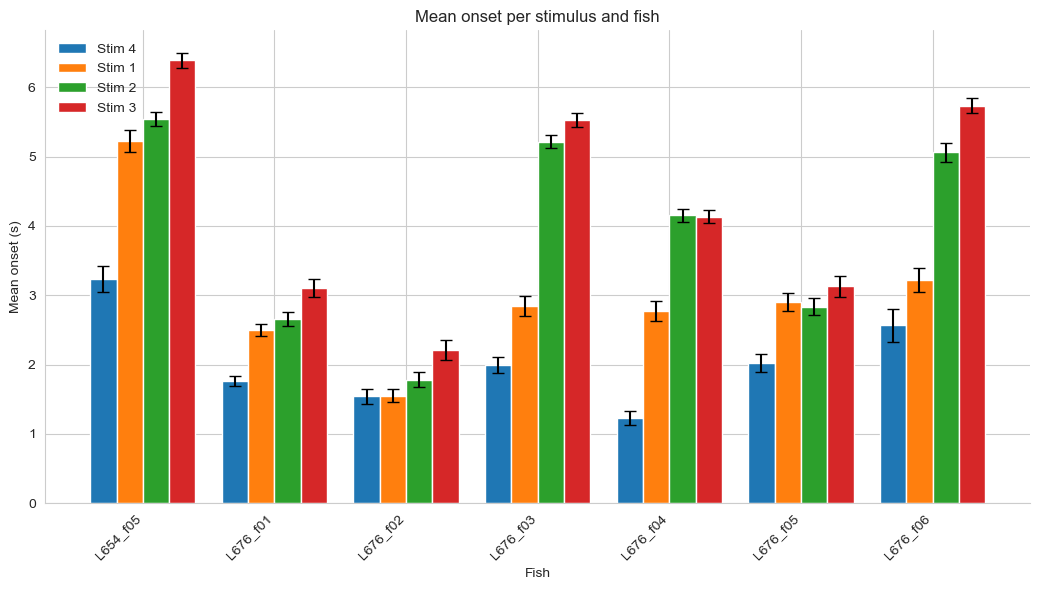

In [34]:
fig1, ax1 = plot_mean_onset_per_fish(
    df_mean_onset,
    fish_order=fish_order,
    stim_order=stim_order,
    error_type="sem",   # or "std" or None
    save_file=save_path / "mean_onset_per_fish_with_errorbars.png",
)

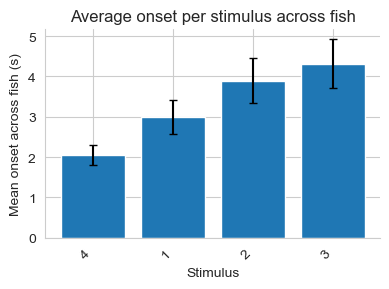

In [41]:
fig2, ax2 = plot_mean_onset_across_fish(
    df_mean_per_stim,
    stim_order=stim_order,
    error_type="sem",   # or "std" or None
    save_file=save_path / "mean_onset_across_fish_with_errorbars.png",
)

plt.show()

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_mean_onsets_all_fish(
    all_fish_data,
    fish_ids=None,
    stim_order=None,
    fps_2p=2.0,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
):
    """
    For each fish:
      - run classify_responses_from_raster
      - compute mean onset per stimulus across neurons (ignoring NaNs)

    Returns
    -------
    df_mean_onset : pd.DataFrame
        Columns:
        - fish_id
        - stim_id
        - mean_onset_sec
        - n_responsive_neurons

    onset_sec_by_id_all : dict
        fish_id -> onset_sec_by_id

    response_type_by_id_all : dict
        fish_id -> response_type_by_id
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    # remove duplicates but keep order
    fish_ids = list(dict.fromkeys(fish_ids))

    if stim_order is None:
        stim_order = all_fish_data[fish_ids[0]]["stimuli_ids"]

    rows = []
    onset_sec_by_id_all = {}
    response_type_by_id_all = {}

    for fid in fish_ids:
        fish = all_fish_data[fid]

        response_type_by_id, onset_sec_by_id = at.classify_responses_from_raster(
            raster=fish["raster"],
            onsets_by_id=fish["onsets_by_id"],
            stimuli_id_map=fish["stimuli_id_map"],
            stimuli_durations=fish["stimuli_durations"],
            fps_2p=fps_2p,
            response_window_sec=response_window_sec,
            min_run_sec=min_run_sec,
            min_fraction_trials=min_fraction_trials,
        )

        onset_sec_by_id_all[fid] = onset_sec_by_id
        response_type_by_id_all[fid] = response_type_by_id

        for stim in stim_order:
            key = stim if stim in onset_sec_by_id else str(stim)
            onset_vec = np.asarray(onset_sec_by_id[key], dtype=float)

            mean_onset = np.nanmean(onset_vec) if np.isfinite(onset_vec).any() else np.nan
            n_resp = np.isfinite(onset_vec).sum()

            rows.append({
                "fish_id": fid,
                "stim_id": stim,
                "mean_onset_sec": mean_onset,
                "n_responsive_neurons": n_resp,
            })

    df_mean_onset = pd.DataFrame(rows)
    return df_mean_onset, onset_sec_by_id_all, response_type_by_id_all




In [18]:
df_mean_onset, onset_sec_by_id_all, response_type_by_id_all = compute_mean_onsets_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,   # duplicates will be removed automatically
    fps_2p=fps_2p,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
)

print(df_mean_onset)

     fish_id  stim_id  mean_onset_sec  n_responsive_neurons
0   L654_f05        1        5.225329                   152
1   L654_f05        2        5.542714                   199
2   L654_f05        3        6.389881                   168
3   L654_f05        4        3.238889                   135
4   L654_f05        5        3.597973                    74
5   L654_f05        6        5.300505                    99
6   L654_f05        7        6.449275                    69
7   L654_f05        8        1.687075                   147
8   L676_f04        1        2.776389                   180
9   L676_f04        2        4.151235                   162
10  L676_f04        3        4.133750                   200
11  L676_f04        4        1.225765                   196
12  L676_f04        5        4.016369                   168
13  L676_f04        6        2.645933                   209
14  L676_f04        7        3.277062                   194
15  L676_f04        8        2.830409   

In [19]:
df_mean_per_stim = (
    df_mean_onset
    .groupby("stim_id", as_index=False)["mean_onset_sec"]
    .mean()
    .rename(columns={"mean_onset_sec": "mean_onset_across_fish_sec"})
)

print(df_mean_per_stim)

   stim_id  mean_onset_across_fish_sec
0        1                    3.002184
1        2                    3.891730
2        3                    4.318403
3        4                    2.049081
4        5                    4.023890
5        6                    4.520328
6        7                    5.143379
7        8                    2.982011


In [20]:
def plot_mean_onset_per_fish(df_mean_onset, stim_order=None, save_file=None):
    if stim_order is None:
        stim_order = df_mean_onset["stim_id"].drop_duplicates().tolist()

    fish_order = df_mean_onset["fish_id"].drop_duplicates().tolist()

    pivot = (
        df_mean_onset
        .pivot(index="fish_id", columns="stim_id", values="mean_onset_sec")
        .reindex(index=fish_order, columns=stim_order)
    )

    x = np.arange(len(fish_order))
    n_stims = len(stim_order)
    width = 0.8 / max(n_stims, 1)

    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(fish_order)), 6))

    for i, stim in enumerate(stim_order):
        xpos = x + (i - (n_stims - 1) / 2) * width
        ax.bar(xpos, pivot[stim].values, width, label=f"Stim {stim}")

    ax.set_xticks(x)
    ax.set_xticklabels(fish_order, rotation=45, ha="right")
    ax.set_ylabel("Mean onset (s)")
    ax.set_xlabel("Fish")
    ax.set_title("Mean onset per stimulus and fish")
    ax.legend(frameon=False)
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax

In [21]:
def plot_mean_onset_across_fish(df_mean_per_stim, save_file=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(df_mean_per_stim["stim_id"].astype(str),
           df_mean_per_stim["mean_onset_across_fish_sec"].values)

    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Mean onset across fish (s)")
    ax.set_title("Average onset per stimulus across fish")
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax

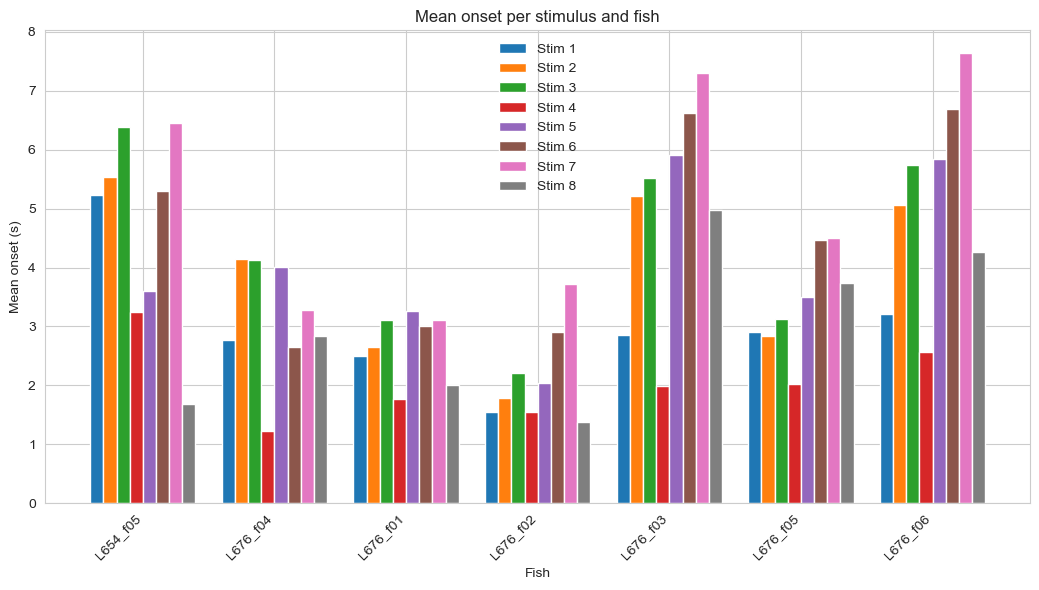

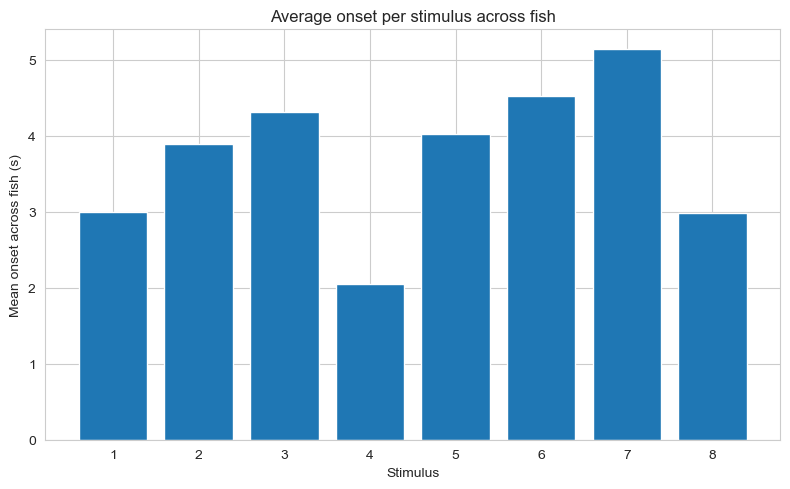

In [22]:
save_path.mkdir(parents=True, exist_ok=True)

stim_order = list(dict.fromkeys(df_mean_onset["stim_id"].tolist()))

fig1, ax1 = plot_mean_onset_per_fish(
    df_mean_onset,
    stim_order=stim_order,
    save_file=save_path / "mean_onset_per_fish.png"
)

fig2, ax2 = plot_mean_onset_across_fish(
    df_mean_per_stim,
    save_file=save_path / "mean_onset_across_fish.png"
)

plt.show()

In [31]:
#{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}



#Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8]
#Stimuli names: ['LBb', 'LBc', 'LBd', 'LB', 'RBb', 'RBc', 'RBd', 'RB']


stim_order = [4,1,2,3,8,5,6,7]
combine_mode = "mean"  # mean or concat
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, is_raster=False)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli

# take trial_aligned_traces from any fish (all have same structure)
fish_id = fish_ids[0]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
print(stimuli_id_map)


Final matrix shape: (570, 592)
{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}


In [2]:
import importlib
import src.plotting as plott
importlib.reload(plott)
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    figsize=(12, 6),
    fish_id="all_fish",
)


save_path.mkdir(parents=True, exist_ok=True)
out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print("✅ Saved:", out_png)


NameError: name 'flat_matrix_all_fish' is not defined

In [3]:
## i just use the same funtons and run per fish to generate a bigger matrix...

In [34]:
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"]
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_norm"]
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(2, 74)
(570, 74)


In [35]:
#Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8]
#Stimuli names: ['LBb', 'LBc', 'LBd', 'LB', 'RBb', 'RBc', 'RBd', 'RB']

stim_order = [4,1,2,3,8,5,6,7]

pre_frames  = int(round(t_pre_s * fps_2p))
post_frames = int(round(t_post_s * fps_2p))
win_lenght = pre_frames + post_frames
frame_window = (pre_frames, win_lenght)
L, R, TI = at.compute_left_right_index(
    mean_traces=concat_mean_traces,
    left_stim=1,   # e.g., FLB = 4
    right_stim=2,
    frame_window=frame_window,
    kept_cells=None,   # or None
)

RL_neuro_order= np.argsort(TI)

Final matrix shape: (570, 592)


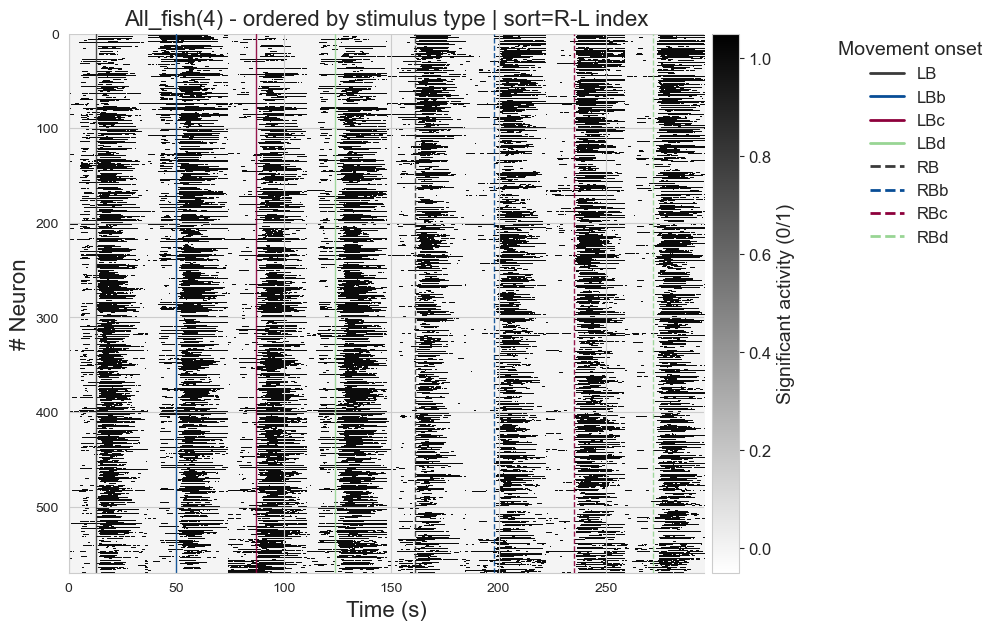

In [36]:

importlib.reload(plott)

# Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# Stimuli names: ['FL1', 'FL2', 'FL3', 'FLB', 'FR1', 'FR2', 'FR3', 'FRB', 'LLB', 'RLB']


is_raster=True
combine_mode = "mean" # mean or concat
M_all= build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode,is_raster= is_raster)
print("Final matrix shape:", M_all.shape)


# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=RL_neuro_order,       # or pass your own `neuron_order`
    sort_label='R-L index',         # optional label override
    is_binary=is_raster,         # True if you pass a 0/1 significance matrix
    figsize=(10, 7),
    fish_id="All_fish(4)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)

new_stimuli_ids:   [8, 5, 6, 7, 4, 1, 2, 3]
new_stimuli_names: ['RB', 'RBb', 'RBc', 'RBd', 'LB', 'LBb', 'LBc', 'LBd']
shape of first M: (2, 74)
[warn] No linestyle for: ['LB', 'LBb', 'LBc', 'LBd'] → using solid '-'.


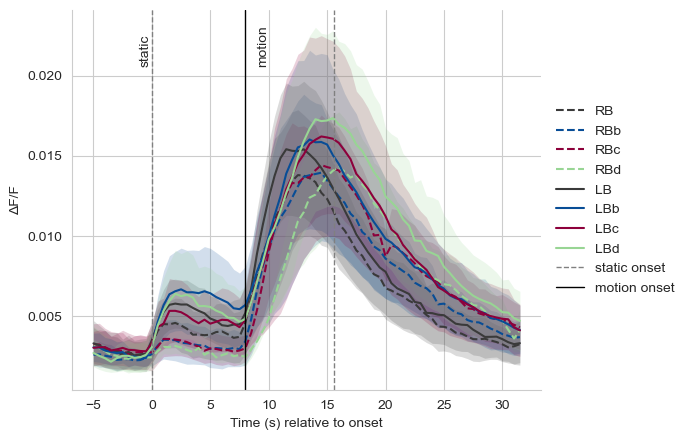

In [37]:
#### identify if
#Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8]
#Stimuli names: ['LBb', 'LBc', 'LBd', 'LB', 'RBb', 'RBc', 'RBd', 'RB']
stim_order = [4,1,2,3,8,5,6,7]


#{'LB': 1, 'RB': 2, 'RL1': 3, 'RL2': 4, 'RL3': 5, 'RLR1': 6, 'RLR2': 7, 'RR1': 8, 'RR2': 9, 'RR3': 10}

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
stimuli_wanted = [7,4,5,6,3,0,1,2] ## rigth
# stimuli_wanted = [4,1,2,3] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)

